In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import numpy as np
import torch.nn as nn
import torch
from torchvision.models import resnet18, ResNet18_Weights
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *



In [2]:
path_train = Path('../data/stage1_train')

df = pd.read_csv('instance_eval_watershed.csv')
df_sorted_error = df.sort_values(by = 'count_error', ascending=False)
df_sorted_map = df.sort_values(by = 'mAP_image')

df_sorted_error.head(5)


,id,n_gt,n_pred,count_error,mAP_image
15,20b20ab049372d184c705acebe7af026d3580f5fd5a72e...,289,9,280,0.000000
56,0ea221716cf13710214dcd331a61cea48308c3940df1d2...,369,139,230,0.003996
64,5afb7932e9c7328f4fb1d7a8166a3699d6cdc5192b9375...,272,127,145,0.006718
22,8efed2e62c919e6d70a2ab548b1a33014877fe8a23f177...,260,139,121,0.005392
16,8d05fb18ee0cda107d56735cafa6197a31884e0a5092dc...,94,0,94,0.000000


In [3]:
df_sorted_map.head(5)

,id,n_gt,n_pred,count_error,mAP_image
13,220b37f4ca7cab486d2b71cd87a46ee7411a5aa142799d...,1,3,2,0.0
15,20b20ab049372d184c705acebe7af026d3580f5fd5a72e...,289,9,280,0.0
8,af576e8ec3a8d0b57eb6a311299e9e4fd2047970d3dd9d...,2,3,1,0.0
16,8d05fb18ee0cda107d56735cafa6197a31884e0a5092dc...,94,0,94,0.0
89,e5aeb5b3577abbebe8982b5dd7d22c4257250ad3000661...,2,1,1,0.0


In [4]:
# Analisar as falhas

top_5_ids = df_sorted_error['id'].head(5).to_list()
top_5_ids

['20b20ab049372d184c705acebe7af026d3580f5fd5a72ed796e3622e1685af2f',
 '0ea221716cf13710214dcd331a61cea48308c3940df1d28cfc7fd817c83714e1',
 '5afb7932e9c7328f4fb1d7a8166a3699d6cdc5192b93758a75e9956f1513c5a3',
 '8efed2e62c919e6d70a2ab548b1a33014877fe8a23f177ef25a9dee25ffe8842',
 '8d05fb18ee0cda107d56735cafa6197a31884e0a5092dc6d41760fb92ae23ab4']

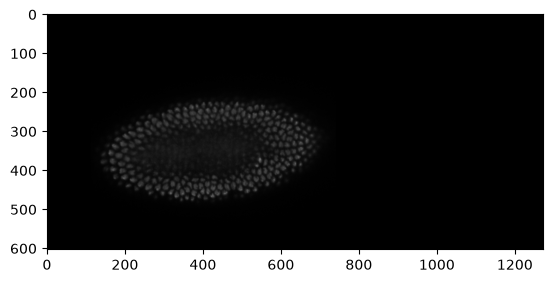

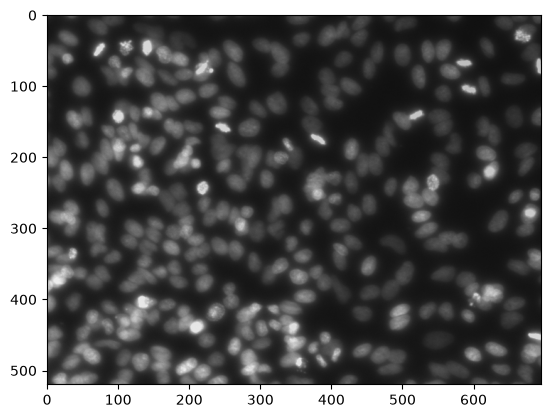

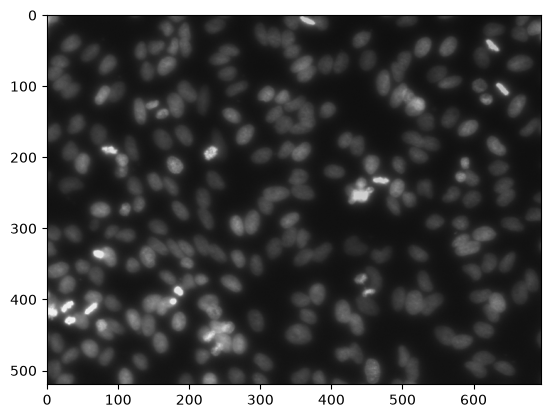

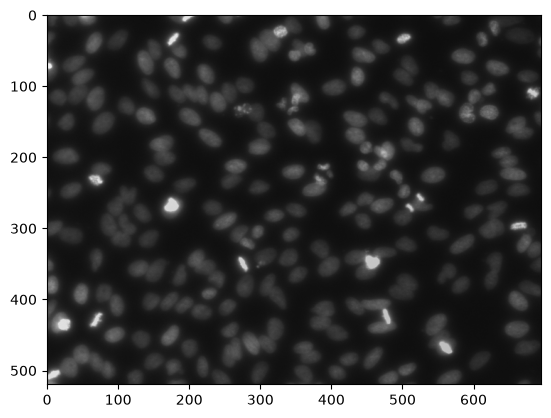

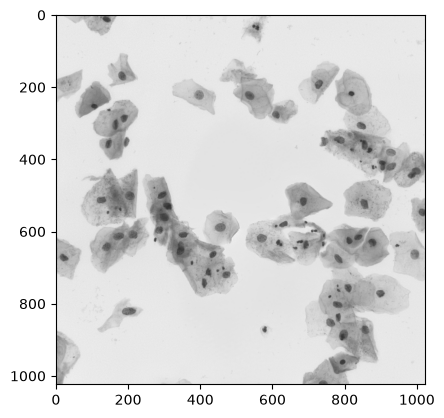

In [5]:
for img_id in top_5_ids:
    img_path = path_train / img_id / 'images' / f'{img_id}.png'
    mask_dir = path_train / img_id / 'masks'

    image = np.array(Image.open(img_path).convert('RGB'))
    plt.imshow(image)
    plt.show()

In [6]:
#  Sugestão de mudança


class UNetTernaryDilated(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1, 
                          replace_stride_with_dilation=(False, True, True))
        
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool = resnet.maxpool
        self.enc2 = resnet.layer1
        self.enc3 = resnet.layer2
        self.enc4 = resnet.layer3

        self.up3 = nn.Conv2d(256, 128, kernel_size=1, stride=1)
        self.dec3 = nn.Sequential(nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.ReLU())
        self.up2 = nn.Conv2d(128, 64, kernel_size=1, stride=1)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.segmentation_head = nn.Conv2d(32, 3, kernel_size=1) # 3 canais (Trilha A)
        
    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        d3 = self.dec3(torch.cat([self.up3(x4), x3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), x2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), x1], dim=1))
        d0 = self.up0(d1)
        
        return self.segmentation_head(d0)